# Learning to Rank for Scientific Document Retrieval

## BM25 Candidate Retrieval and Pairwise Reranking

This notebook develops a two stage information retrieval system:

1. **BM25** retrieves an initial set of candidate documents.
2. A supervised **pairwise Learning-to-Rank model** reranks those candidates.

Unlike ordinary classification, the objective is not to predict an isolated
document label. The model learns which of two documents should appear higher
for the same query.

The system is evaluated using query-level information retrieval metrics:

- nDCG@10
- MAP@10
- MRR@10
- Recall@50

The Cranfield collection data is utilized because it provides queries, scientific
documents, and graded relevance judgments.

In [1]:
import re
import warnings
from collections import Counter

import ir_datasets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display
from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
CANDIDATE_K = 100

In [2]:
dataset = ir_datasets.load("cranfield")

docs = pd.DataFrame([doc._asdict() for doc in dataset.docs_iter()])
queries = pd.DataFrame([query._asdict() for query in dataset.queries_iter()])
qrels = pd.DataFrame([qrel._asdict() for qrel in dataset.qrels_iter()])

docs["content"] = docs["title"].fillna("") + " " + docs["text"].fillna("")
qrels["relevance"] = pd.to_numeric(qrels["relevance"]).clip(lower=0)

print(f"Documents: {len(docs):,}")
print(f"Queries: {len(queries):,}")
print(f"Relevance judgments: {len(qrels):,}")

display(docs[["doc_id", "title"]].head())
display(queries.head())

[INFO] [starting] http://ir.dcs.gla.ac.uk/resources/test_collections/cran/cran.tar.gz
[INFO] [finished] http://ir.dcs.gla.ac.uk/resources/test_collections/cran/cran.tar.gz: [00:01] [507kB] [285kB/s]


Documents: 1,400
Queries: 225
Relevance judgments: 1,837


,doc_id,title
0,1,experimental investigation of the aerodynamics...
1,2,simple shear flow past a flat plate in an inco...
2,3,the boundary layer in simple shear flow past a...
3,4,approximate solutions of the incompressible la...
4,5,one-dimensional transient heat conduction into...


,query_id,text
0,1,what similarity laws must be obeyed when const...
1,2,what are the structural and aeroelastic proble...
2,3,what problems of heat conduction in composite ...
3,4,can a criterion be developed to show empirical...
4,5,what chemical kinetic system is applicable to ...


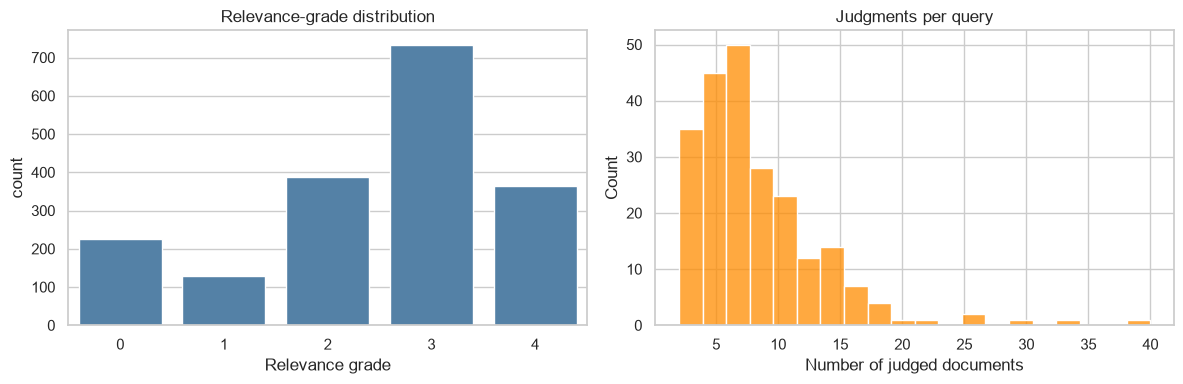

,count
relevance,
0,225
1,128
2,387
3,734
4,363


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=qrels, x="relevance", color="steelblue", ax=axes[0])
axes[0].set_title("Relevance-grade distribution")
axes[0].set_xlabel("Relevance grade")

judgments_per_query = qrels.groupby("query_id").size()
sns.histplot(judgments_per_query, bins=20, color="darkorange", ax=axes[1])
axes[1].set_title("Judgments per query")
axes[1].set_xlabel("Number of judged documents")

plt.tight_layout()
plt.show()

qrels.groupby("relevance").size().rename("count").to_frame()

## Initial data observations

- The collection contains **1,400 documents**, **225 queries**, and **1,837 relevance judgments**.
- There were approximately **8.2 judgments per query on average**.
- Relevance grade **3** was the most common, appearing in 734 judgments. Grades 2–4 accounted for most of the assessed query–document pairs.
- The dataset therefore provides graded relevance rather than only binary relevant/non-relevant labels. This makes nDCG particularly useful because it rewards placing more highly relevant documents near the top.
- The original non-relevant assessments were represented as grade 0 after preprocessing. Documents without a judgment are also treated as non-relevant during this experiment.

## First-stage retrieval

BM25 is used to efficiently retrieve a shortlist of candidate documents.

The later ML model only reranks these candidates. Therefore, documents missed
by BM25 cannot be recovered by the reranker. Candidate recall is consequently
an important upper-bound diagnostic.

In [4]:
TOKEN_PATTERN = re.compile(r"\b[a-zA-Z][a-zA-Z0-9-]*\b")

def tokenize(text):
    return TOKEN_PATTERN.findall(str(text).lower())

doc_tokens = docs["content"].map(tokenize).tolist()
bm25 = BM25Okapi(doc_tokens)

tfidf = TfidfVectorizer(tokenizer=tokenize, token_pattern=None, lowercase=False)
doc_tfidf = tfidf.fit_transform(docs["content"])

idf_lookup = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))
doc_id_to_index = pd.Series(docs.index, index=docs["doc_id"]).to_dict()

print(f"BM25 documents indexed: {len(doc_tokens):,}")
print(f"TF-IDF vocabulary size: {len(idf_lookup):,}")

BM25 documents indexed: 1,400
TF-IDF vocabulary size: 8,437


## Ranking features

For each query, BM25 retrieves the top 100 documents. The following lexical
features are then calculated for every query–document pair:

- Normalized BM25 score
- TF-IDF cosine similarity
- Proportion of query terms matched
- Total IDF of matched terms
- Frequency of query terms in the document
- Exact query-phrase match
- Document length
- Document-to-query length ratio

The relevance judgment is the supervised target and is never included as an
input feature.

In [5]:
qrel_lookup = qrels.groupby(["query_id", "doc_id"])["relevance"].max().to_dict()

def build_query_candidates(query_id, query_text, k=CANDIDATE_K):
    q_tokens = tokenize(query_text)
    bm25_scores = np.asarray(bm25.get_scores(q_tokens))
    top_indices = np.argsort(bm25_scores)[::-1][:k]
    cosine_scores = (tfidf.transform([query_text]) @ doc_tfidf.T).toarray().ravel()

    top_scores = bm25_scores[top_indices]
    score_mean, score_std = top_scores.mean(), top_scores.std() + 1e-9
    query_terms = set(q_tokens)
    normalized_query = " ".join(q_tokens)
    rows = []

    for index in top_indices:
        counts = Counter(doc_tokens[index])
        matched = query_terms.intersection(counts)
        doc_length = len(doc_tokens[index])
        doc_id = docs.at[index, "doc_id"]

        rows.append({
            "query_id": query_id,
            "doc_id": doc_id,
            "bm25_score": bm25_scores[index],
            "bm25_z": (bm25_scores[index] - score_mean) / score_std,
            "tfidf_cosine": cosine_scores[index],
            "query_coverage": len(matched) / max(len(query_terms), 1),
            "matched_idf": sum(idf_lookup.get(term, 0) for term in matched),
            "term_frequency": sum(counts[term] for term in matched),
            "exact_phrase": int(normalized_query in " ".join(doc_tokens[index])),
            "log_doc_length": np.log1p(doc_length),
            "length_ratio": np.log1p(doc_length / max(len(q_tokens), 1)),
            "relevance": qrel_lookup.get((query_id, doc_id), 0)
        })

    return rows

In [6]:
candidate_rows = []

for query in queries.itertuples(index=False):
    candidate_rows.extend(build_query_candidates(query.query_id, query.text))

candidates = pd.DataFrame(candidate_rows)

print(f"Candidate query-document pairs: {len(candidates):,}")
display(candidates.head())

Candidate query-document pairs: 22,500


,query_id,doc_id,bm25_score,bm25_z,tfidf_cosine,query_coverage,matched_idf,term_frequency,exact_phrase,log_doc_length,length_ratio,relevance
0,1,13,24.751653,4.195835,0.285665,0.333333,17.770273,20,0,4.976734,2.360854,4
1,1,486,23.670989,3.847389,0.166750,0.400000,22.302618,21,0,5.411646,2.764220,0
2,1,12,21.229720,3.060233,0.157729,0.333333,16.925043,20,0,4.882802,2.275556,3
3,1,184,18.728658,2.253797,0.153631,0.400000,17.953582,17,0,4.997212,2.379546,2
4,1,51,18.577736,2.205134,0.171636,0.400000,18.626526,32,0,5.365976,2.721295,3


count    225.000
mean       0.662
std        0.289
min        0.000
25%        0.500
50%        0.692
75%        0.909
max        1.000
Name: doc_id, dtype: float64

Mean Recall@100: 0.662


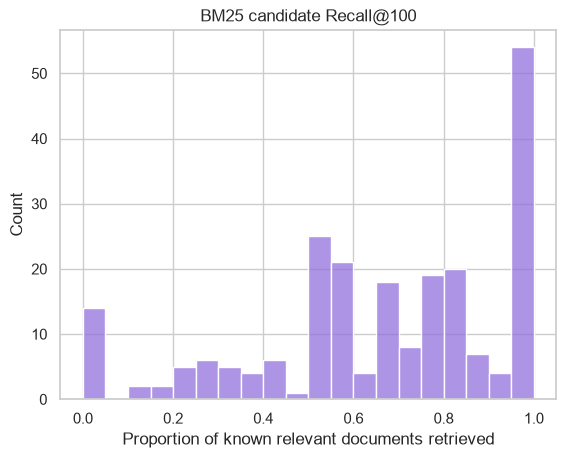

In [7]:
total_relevant = qrels[qrels["relevance"] > 0].groupby("query_id")["doc_id"].nunique()
retrieved_relevant = candidates[candidates["relevance"] > 0].groupby("query_id")["doc_id"].nunique()

candidate_recall = (
    retrieved_relevant.reindex(queries["query_id"], fill_value=0)
    / total_relevant.reindex(queries["query_id"])
).dropna()

print(candidate_recall.describe().round(3))
print(f"\nMean Recall@{CANDIDATE_K}: {candidate_recall.mean():.3f}")

sns.histplot(candidate_recall, bins=20, color="mediumpurple")
plt.title(f"BM25 candidate Recall@{CANDIDATE_K}")
plt.xlabel("Proportion of known relevant documents retrieved")
plt.show()

## Candidate-generation findings

- BM25 achieved a mean candidate **Recall@100 of 0.662**, meaning that approximately **66.2%** of known relevant documents were available to the reranker.
- Candidate recall varied considerably across queries, from **0.000 to 1.000**, with a median of **0.692**.
- Twenty-five percent of queries had recall at or below **0.500**, while the upper quartile reached approximately **0.909**.
- BM25 therefore provided **moderate but uneven coverage**. Some queries had nearly complete candidate sets, whereas others were missing many relevant documents.
- This is an important ceiling on performance: the Learning-to-Rank model can reorder the top 100 candidates but cannot recover relevant documents that BM25 failed to retrieve.

## Leakage-safe validation

The split is performed by query rather than by query–document row.

If candidate rows were randomly divided, documents from the same query could
appear in both training and testing. That would give an unrealistically
optimistic estimate of ranking performance.

In [8]:
query_ids = queries["query_id"].to_numpy()

train_ids, test_ids = train_test_split(
    query_ids, test_size=0.20, random_state=RANDOM_STATE
)
train_ids, validation_ids = train_test_split(
    train_ids, test_size=0.25, random_state=RANDOM_STATE
)

print(f"Training queries:   {len(train_ids)}")
print(f"Validation queries: {len(validation_ids)}")
print(f"Test queries:       {len(test_ids)}")

Training queries:   135
Validation queries: 45
Test queries:       45


## Pairwise Learning to Rank

For documents belonging to the same query, the model receives feature
differences:

\[
x_{pair} = x_{\text{more relevant}} - x_{\text{less relevant}}
\]

The target indicates which ordering is correct. This converts ranking into a
binary supervised-learning problem while preserving the relative nature of
document relevance.

A logistic regression model is used as a compact RankNet/RankSVM-style linear
pairwise ranker.

In [9]:
FEATURES = [
    "bm25_z", "tfidf_cosine", "query_coverage", "matched_idf",
    "term_frequency", "exact_phrase", "log_doc_length", "length_ratio"
]

def make_pairwise_data(frame, max_pairs_per_query=250, random_state=42):
    rng = np.random.default_rng(random_state)
    pair_features, pair_labels = [], []

    for _, group in frame.groupby("query_id"):
        X = group[FEATURES].to_numpy(float)
        relevance = group["relevance"].to_numpy()
        pairs = np.argwhere(relevance[:, None] > relevance[None, :])

        if len(pairs) > max_pairs_per_query:
            pairs = pairs[rng.choice(len(pairs), max_pairs_per_query, replace=False)]
        if not len(pairs):
            continue

        differences = X[pairs[:, 0]] - X[pairs[:, 1]]
        pair_features.extend([differences, -differences])
        pair_labels.extend([np.ones(len(differences)), np.zeros(len(differences))])

    return np.vstack(pair_features), np.concatenate(pair_labels)

train_candidates = candidates[candidates["query_id"].isin(train_ids)]
X_pair, y_pair = make_pairwise_data(train_candidates)

print(f"Pairwise training examples: {len(y_pair):,}")
print(pd.Series(y_pair).value_counts().sort_index())

Pairwise training examples: 57,204
0.0    28602
1.0    28602
Name: count, dtype: int64


In [10]:
truth_by_query = {
    query_id: group.set_index("doc_id")["relevance"].to_dict()
    for query_id, group in qrels.groupby("query_id")
}

def dcg(grades):
    grades = np.asarray(grades, dtype=float)
    return np.sum((2 ** grades - 1) / np.log2(np.arange(2, len(grades) + 2)))

def evaluate_queries(frame, query_subset, score_column):
    results = []

    for query_id in query_subset:
        ranked = frame[frame["query_id"] == query_id].sort_values(score_column, ascending=False)
        truth = truth_by_query.get(query_id, {})
        grades = ranked["doc_id"].map(truth).fillna(0).to_numpy()
        all_grades = np.asarray(list(truth.values()))
        total_relevant = np.sum(all_grades > 0)

        top10 = grades[:10]
        hits10 = top10 > 0
        ideal10 = np.sort(all_grades)[::-1][:10]
        ndcg10 = dcg(top10) / dcg(ideal10) if dcg(ideal10) else 0
        ap10 = np.sum(np.cumsum(hits10) / np.arange(1, len(top10) + 1) * hits10)
        ap10 /= min(total_relevant, 10) if total_relevant else 1
        rr10 = 1 / (np.flatnonzero(hits10)[0] + 1) if hits10.any() else 0
        recall50 = np.sum(grades[:50] > 0) / total_relevant if total_relevant else 0

        results.append({
            "query_id": query_id, "nDCG@10": ndcg10,
            "AP@10": ap10, "RR@10": rr10, "Recall@50": recall50
        })

    return pd.DataFrame(results)

In [11]:
def make_ranker(C):
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(C=C, fit_intercept=False, max_iter=2000, random_state=RANDOM_STATE)
    )

def add_ranker_scores(frame, model):
    scored = frame.copy()
    scored["ltr_score"] = model.decision_function(scored[FEATURES])
    return scored

validation_results = []

for C in [0.01, 0.1, 1, 10]:
    ranker = make_ranker(C)
    ranker.fit(X_pair, y_pair)
    scored = add_ranker_scores(candidates, ranker)
    metrics = evaluate_queries(scored, validation_ids, "ltr_score")
    validation_results.append({"C": C, **metrics.drop(columns="query_id").mean().to_dict()})

validation_results = pd.DataFrame(validation_results)
best_c = validation_results.loc[validation_results["nDCG@10"].idxmax(), "C"]

display(validation_results.round(4))
print(f"Selected C: {best_c}")

,C,nDCG@10,AP@10,RR@10,Recall@50
0,0.01,0.2437,0.1845,0.4508,0.5899
1,0.10,0.2400,0.1823,0.4482,0.5905
2,1.00,0.2421,0.1830,0.4560,0.5845
3,10.00,0.2429,0.1843,0.4560,0.5845


Selected C: 0.01


## Model selection findings

- Regularization value **C = 0.01** produced the highest validation nDCG@10 of **0.2437**.
- The other tested settings produced nDCG@10 values between **0.2400 and 0.2429**.
- Performance was therefore relatively stable across the tested regularization strengths, with a maximum nDCG difference of only **0.0037**.
- This suggests that regularization had limited influence on the learned ordering and that the ranking was driven mainly by the available lexical features.
- The model with C = 0.01 was selected using validation queries only and was then refitted on the combined training and validation queries before final test evaluation.

In [12]:
development_ids = np.concatenate([train_ids, validation_ids])
development_candidates = candidates[candidates["query_id"].isin(development_ids)]
X_development, y_development = make_pairwise_data(development_candidates)

final_ranker = make_ranker(best_c)
final_ranker.fit(X_development, y_development)
scored_candidates = add_ranker_scores(candidates, final_ranker)

bm25_test = evaluate_queries(scored_candidates, test_ids, "bm25_score")
ltr_test = evaluate_queries(scored_candidates, test_ids, "ltr_score")

comparison = pd.DataFrame({
    "BM25": bm25_test.drop(columns="query_id").mean(),
    "Pairwise LTR": ltr_test.drop(columns="query_id").mean()
}).T.rename(columns={"AP@10": "MAP@10", "RR@10": "MRR@10"})

comparison["nDCG improvement"] = comparison["nDCG@10"] - comparison.loc["BM25", "nDCG@10"]
comparison.round(4)

,nDCG@10,MAP@10,MRR@10,Recall@50,nDCG improvement
BM25,0.2888,0.2413,0.5574,0.5754,0.0000
Pairwise LTR,0.3071,0.2351,0.5589,0.5748,0.0184


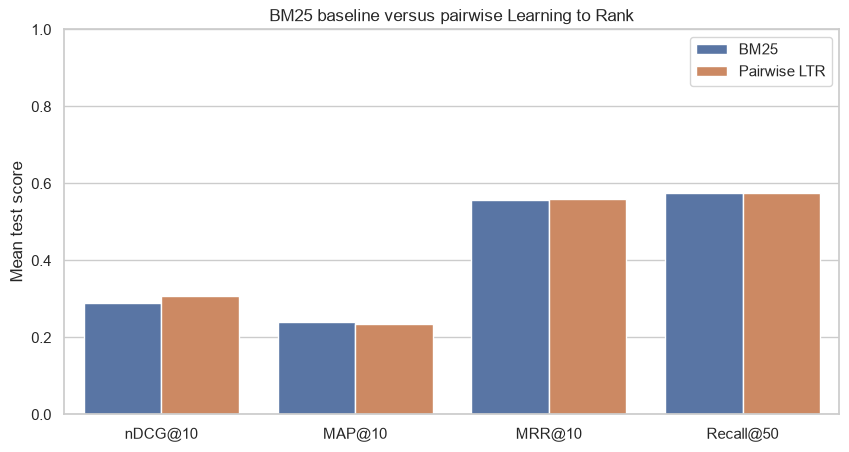

In [13]:
plot_data = comparison.drop(columns="nDCG improvement").reset_index(names="method")
plot_data = plot_data.melt(id_vars="method", var_name="metric", value_name="score")

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_data, x="metric", y="score", hue="method")
plt.ylim(0, 1)
plt.title("BM25 baseline versus pairwise Learning to Rank")
plt.xlabel("")
plt.ylabel("Mean test score")
plt.legend(title="")
plt.show()

Mean nDCG@10 difference: 0.0184
95% bootstrap interval: [-0.0096, 0.0461]


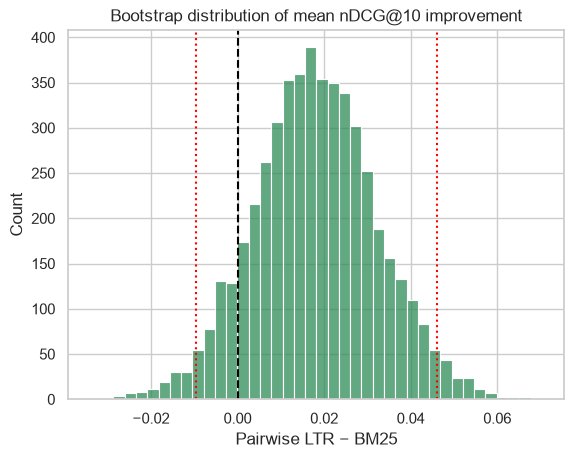

In [14]:
ndcg_difference = ltr_test["nDCG@10"].to_numpy() - bm25_test["nDCG@10"].to_numpy()

rng = np.random.default_rng(RANDOM_STATE)
bootstrap_means = np.array([
    rng.choice(ndcg_difference, len(ndcg_difference), replace=True).mean()
    for _ in range(5000)
])

lower, upper = np.quantile(bootstrap_means, [0.025, 0.975])

print(f"Mean nDCG@10 difference: {ndcg_difference.mean():.4f}")
print(f"95% bootstrap interval: [{lower:.4f}, {upper:.4f}]")

sns.histplot(bootstrap_means, bins=40, color="seagreen")
plt.axvline(0, color="black", linestyle="--")
plt.axvline(lower, color="red", linestyle=":")
plt.axvline(upper, color="red", linestyle=":")
plt.title("Bootstrap distribution of mean nDCG@10 improvement")
plt.xlabel("Pairwise LTR − BM25")
plt.show()

## Test set ranking results

- BM25 achieved **nDCG@10 = 0.2888**, while the pairwise ranker achieved **0.3071**.
- This was an absolute improvement of **0.0184**, equivalent to approximately a **6.4% relative increase** in nDCG@10.
- MAP@10 decreased slightly from **0.2413 to 0.2351**.
- MRR@10 remained almost unchanged, increasing from **0.5574 to 0.5589**.
- Recall@50 also remained effectively unchanged, decreasing from **0.5754 to 0.5748**.
- The 95% bootstrap interval for the mean nDCG@10 improvement was **[-0.0096, 0.0461]**.
- Because this interval includes zero, there is **insufficient evidence that the nDCG improvement is consistent across unseen queries**.
- Overall, the model improved the ordering of graded relevance near the top, but it did not improve binary relevant-document coverage or first-relevant-document ranking.
- The near-identical Recall@50 is expected because the model reranks BM25 candidates rather than retrieving additional documents.

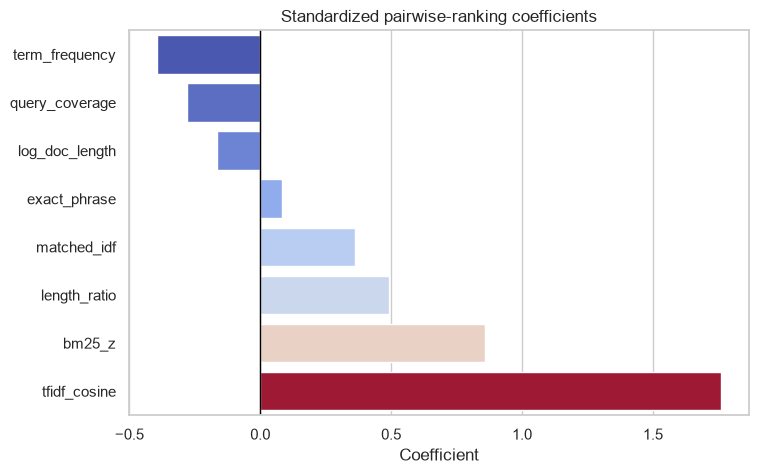

,feature,coefficient
4,term_frequency,-0.393057
2,query_coverage,-0.279549
6,log_doc_length,-0.163944
5,exact_phrase,0.083291
3,matched_idf,0.363203
7,length_ratio,0.493431
0,bm25_z,0.857377
1,tfidf_cosine,1.760161


In [15]:
coefficients = final_ranker.named_steps["logisticregression"].coef_[0]
importance = pd.DataFrame({"feature": FEATURES, "coefficient": coefficients})
importance = importance.sort_values("coefficient")

plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x="coefficient", y="feature", hue="coefficient",
            palette="coolwarm", legend=False)
plt.axvline(0, color="black", linewidth=1)
plt.title("Standardized pairwise-ranking coefficients")
plt.xlabel("Coefficient")
plt.ylabel("")
plt.show()

importance

## Feature interpretation

- **TF-IDF cosine similarity** was the strongest positive feature, with a coefficient of **1.760**. Documents whose term distributions closely matched the query were therefore strongly promoted.
- The normalized **BM25 score** was the second strongest positive feature at **0.857**, showing that the model retained substantial reliance on the original BM25 ranking.
- Length ratio (**0.493**), matched IDF (**0.363**), and exact-phrase matching (**0.083**) also had positive effects.
- The strongest negative coefficient belonged to raw term frequency at **-0.393**. After accounting for BM25, TF-IDF similarity, and matched-term importance, repeated query terms alone did not indicate greater relevance.
- Query coverage (**-0.280**) and document length (**-0.164**) also had negative conditional coefficients.
- Some apparently counterintuitive coefficients are likely caused by correlation between BM25, cosine similarity, coverage, term frequency, and document-length features.
- The coefficients should therefore be interpreted as conditional associations within this model rather than independent or causal effects.

In [16]:
query_gains = ltr_test[["query_id", "nDCG@10"]].merge(
    bm25_test[["query_id", "nDCG@10"]], on="query_id", suffixes=("_ltr", "_bm25")
)
query_gains["gain"] = query_gains["nDCG@10_ltr"] - query_gains["nDCG@10_bm25"]

query_text_lookup = queries.set_index("query_id")["text"].to_dict()
title_lookup = docs.set_index("doc_id")["title"].to_dict()

def show_ranking(query_id, score_column, heading, n=5):
    ranking = scored_candidates[scored_candidates["query_id"] == query_id]
    ranking = ranking.sort_values(score_column, ascending=False).head(n).copy()
    ranking["title"] = ranking["doc_id"].map(title_lookup)
    ranking["score"] = ranking[score_column]
    display(Markdown(f"**{heading}**"))
    display(ranking[["doc_id", "relevance", "score", "title"]].round(3))

best_query = query_gains.loc[query_gains["gain"].idxmax(), "query_id"]
worst_query = query_gains.loc[query_gains["gain"].idxmin(), "query_id"]

for label, query_id in [("Largest improvement", best_query), ("Largest decline", worst_query)]:
    display(Markdown(f"### {label}\n\n**Query:** {query_text_lookup[query_id]}"))
    show_ranking(query_id, "bm25_score", "BM25 top five")
    show_ranking(query_id, "ltr_score", "Learning-to-Rank top five")

### Largest improvement

**Query:** what papers are there dealing with circumferential buckling either
thermal buckling or due to mechanical loading .

**BM25 top five**

,doc_id,relevance,score,title
12000,769,0,31.837,local circumferential buckling of thin circula...
12001,887,1,31.483,buckling due to thermal stress of cylindrical ...
12002,1146,2,29.768,thermal buckling of cylinders .
12003,888,1,27.306,combinations of temperature and axial compress...
12004,890,1,26.367,comments on 'thermal buckling of clamped cylin...


**Learning-to-Rank top five**

,doc_id,relevance,score,title
12002,1146,2,5.640,thermal buckling of cylinders .
12001,887,1,5.458,buckling due to thermal stress of cylindrical ...
12000,769,0,5.021,local circumferential buckling of thin circula...
12003,888,1,4.408,combinations of temperature and axial compress...
12005,837,0,4.012,inelastic behaviour of structures subjected to...


### Largest decline

**Query:** references on lyapunov's method on the stability of linear
differential equations with periodic coefficients .

**BM25 top five**

,doc_id,relevance,score,title
17200,367,1,38.138,control system and analysis and design via the...
17201,451,1,35.719,liapunov's methods in automatic control theory .
17202,532,0,30.011,pitch-yaw stability of a missile oscillating i...
17203,703,0,24.610,general airfoil theory .
17204,731,0,23.561,upper and lower bounds for the solution of the...


**Learning-to-Rank top five**

,doc_id,relevance,score,title
17202,532,0,6.738,pitch-yaw stability of a missile oscillating i...
17200,367,1,6.472,control system and analysis and design via the...
17201,451,1,4.975,liapunov's methods in automatic control theory .
17203,703,0,2.783,general airfoil theory .
17208,91,0,2.573,periodic temperature distribution in a two-lay...


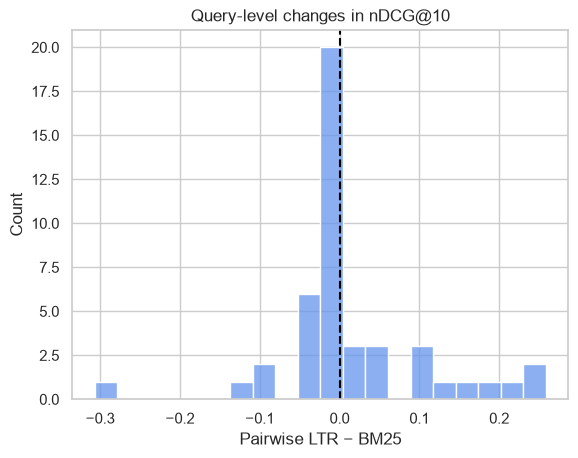

Queries improved: 15
Queries unchanged: 17
Queries degraded: 13


In [17]:
sns.histplot(query_gains["gain"], bins=20, color="cornflowerblue")
plt.axvline(0, color="black", linestyle="--")
plt.title("Query-level changes in nDCG@10")
plt.xlabel("Pairwise LTR − BM25")
plt.show()

print(f"Queries improved: {(query_gains['gain'] > 0).sum()}")
print(f"Queries unchanged: {(query_gains['gain'] == 0).sum()}")
print(f"Queries degraded: {(query_gains['gain'] < 0).sum()}")

## Query-level error analysis

- The learned model improved **15** test queries, left **17** unchanged, and degraded **13**.
- The largest improvement occurred for the query asking whether previous analyses of **circumferential thermal buckling of circular cylindrical shells** were unnecessarily complicated or inaccurate.
- For this query, the model moved document 1146, *Thermal Buckling of Cylinders*, from rank 3 to rank 1. This document had relevance grade 2.
- It also moved the unjudged/non-relevant document 769 from rank 1 to rank 3. Promoting the more relevant thermal-buckling document produced a substantial nDCG improvement.
- The largest decline occurred for the query requesting references on **Lyapunov's method for the stability of linear differential equations with periodic coefficients**.
- BM25 originally placed relevant documents 367 and 451 at ranks 1 and 2. The reranker promoted non-relevant document 532 to rank 1 and moved those relevant documents to ranks 2 and 3.
- Document 532 contains lexically related concepts such as stability and oscillation but does not address the requested Lyapunov method. This is an example of lexical similarity failing to capture the precise semantic information need.
- The mixed query-level results show that the average nDCG gain was concentrated in a subset of queries and was not a universal improvement.

# Conclusion

This project combined traditional information retrieval with supervised
Learning to Rank. BM25 first retrieved 100 candidate documents for each query,
after which a pairwise logistic regression model learned document preferences
from graded relevance judgments.

On 45 unseen test queries, the learned reranker increased nDCG@10 from
**0.2888 to 0.3071**, representing an absolute improvement of **0.0184** and
a relative improvement of approximately **6.4%**. This indicates that the
model produced a somewhat better ordering of highly relevant documents near
the top of the results.

However, MAP@10 decreased from **0.2413 to 0.2351**, while MRR@10 and Recall@50
remained almost unchanged. The bootstrap confidence interval of
**[-0.0096, 0.0461]** also included zero. The experiment therefore provides
promising but inconclusive evidence that the learned ranker consistently
outperforms BM25.

TF-IDF cosine similarity and the original BM25 score were the most influential
positive features. This shows that the model mainly learned a more flexible
combination of existing lexical relevance signals rather than an entirely new
notion of semantic relevance.

Query-level analysis found 15 improvements, 17 unchanged results, and 13
declines. The best case successfully promoted a more relevant thermal-buckling
document, while the worst case promoted a lexically similar but semantically
incorrect document for a Lyapunov-method query.

The main limitation was BM25 candidate Recall@100 of **0.662**. Because the
reranker cannot recover documents outside the candidate set, missing relevant
documents restricted its maximum possible performance. Other limitations
include the small specialized collection, correlated lexical features, and
the treatment of unjudged documents as non-relevant.

A natural extension would combine BM25 with semantic embeddings or a
transformer cross-encoder. These models could better distinguish documents
that share vocabulary from documents that actually answer the query, while
retaining the same query-level split and IR evaluation procedure.